In [82]:
import os
import seaborn as sns
import s3fs
from dotenv import load_dotenv
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics

#load the environment variables from the .env file
load_dotenv(override=True)

#load the dataset stored in the s3 bucket of MinIO
fs=s3fs.S3FileSystem(key=os.getenv("AWS_ACCESS_KEY_ID"), 
                  secret=os.getenv("AWS_SECRET_ACCESS_KEY"),
                  token=os.getenv("AWS_SESSION_TOKEN"),
                  client_kwargs={'endpoint_url':  'https://'+ os.getenv("AWS_S3_ENDPOINT")})


#load the train dataset
train_path= os.getenv("AWS_BUCKET_NAME") + '/train.csv'
with fs.open(train_path, mode='rb') as f:
        df = pd.read_csv(f)

loan_status
0    85.761787
1    14.238213
Name: count, dtype: float64


<Axes: >

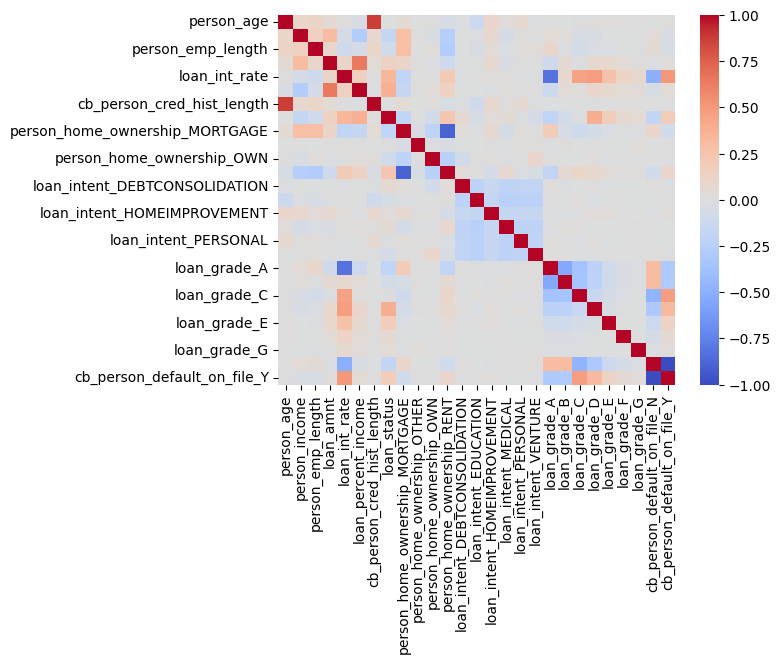

In [83]:
# Exploratory analysis

#drop index column
df.drop(columns=["id"], inplace=True)

print(df["loan_status"].value_counts()/len(df)*100) #train sample with imbalanced classes

#convert the str columns to dummy variables (one-hot encoding)
df = pd.get_dummies(df, columns=df.select_dtypes(include='str').columns, dtype=int)

sns.heatmap(df.corr(), cmap="coolwarm") 

In [77]:
len(df.columns)

27

In [52]:
#Split train and validation sets
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val= train_test_split(df.drop(columns=["loan_status"]), df["loan_status"], test_size=0.2, random_state=42)

In [86]:

rf=RandomForestClassifier(n_estimators=100, criterion="gini", oob_score=True, random_state=42)
rf.fit(X_train, y_train)

#metrics: f1 and recall (more relevant metrics for imbalanced datasets)
print("F1 Score:", metrics.f1_score(y_val, rf.predict(X_val))) #poor f1 (imbalanced dataset)
print("Recall Score:", metrics.recall_score(y_val, rf.predict(X_val))) #especially poor recall (many false negatives)

F1 Score: 0.810608636518191
Recall Score: 0.7259439707673568


In [ ]:
#random forest with balanced option to handle class imbalance
rf=RandomForestClassifier(n_estimators=100, class_weight="balanced", criterion="gini", oob_score=True, random_state=42)
rf.fit(X_train, y_train)
rf.score(X_val, y_val)
print("F1 Score:", metrics.f1_score(y_val, rf.predict(X_val))) #poor f1 (imbalanced dataset)
print("Recall Score:", metrics.recall_score(y_val, rf.predict(X_val)))

#...worse

F1 Score: 0.8076923076923077
Recall Score: 0.7161997563946407


In [91]:
from xgboost import XGBClassifier, LGBMClassifier

scale = (58000 * 0.86) / (58000 * 0.14)  # ≈ 6.1
xgb = XGBClassifier(scale_pos_weight=scale, random_state=42)

# LightGBM
lgbm = LGBMClassifier(is_unbalance=True, random_state=42)

ModuleNotFoundError: No module named 'xgboost'